In [1]:
import sionna
import matplotlib.pyplot as plt
import numpy as np
from sionna.rt import load_scene, Camera, Transmitter, Receiver, PlanarArray, PathSolver, RadioMap, RadioMapSolver

In [ ]:
scene = load_scene("/Users/epiphanyer/coding/test/blender_scene/paris/paris.xml")

In [4]:
scene.tx_array = PlanarArray(
    num_rows=4,              # 阵列在垂直方向上的阵元行数（4 行）
    num_cols=4,              # 阵列在水平方向上的阵元列数（4 列）
    vertical_spacing=0.5,    # 垂直方向阵元间距，单位为波长 λ（0.5λ）
    horizontal_spacing=0.5,  # 水平方向阵元间距，单位为波长 λ（0.5λ）
    pattern="tr38901",       # 天线方向图，采用 3GPP TR 38.901 规范中的基站方向图模型
    polarization="V"         # 天线极化方式：V 表示垂直极化（Vertical polarization）
)


# ============================
# 接收端（RX）天线阵列配置
# ============================
# 该配置对场景中所有接收机（RX）生效，这里使用单天线模型，
# 通常用于模拟用户终端（UE）

scene.rx_array = PlanarArray(
    num_rows=1,              # 垂直方向阵元数为 1（单天线）
    num_cols=1,              # 水平方向阵元数为 1（单天线）
    vertical_spacing=0.5,    # 阵元间距参数（单阵元时不影响几何结构）
    horizontal_spacing=0.5,  # 阵元间距参数（单阵元时不影响几何结构）
    pattern="iso",           # 各向同性天线方向图（isotropic antenna）
    polarization="V"         # 极化方式：垂直极化
)

In [5]:
tx = Transmitter(
    name="t2",                 # 发射机名称，用于在场景中唯一标识该 TX
    position=[-66, -52, 22],   # 发射机在三维空间中的位置坐标 [x, y, z]，单位：米
    orientation=[47.0, 0.0, -104.0]# 发射机的姿态角 [yaw, pitch, roll]，单位：弧度（rad）
                               # yaw：绕 z 轴旋转（方位角）
                               # pitch：绕 y 轴旋转（俯仰角）
                               # roll：绕 x 轴旋转（翻滚角）
)
if "t2" not in scene.transmitters:
    scene.add(tx)                  # 将发射机加入场景，使其参与射线追踪与信道计算
    
# ============================
# 接收机（Receiver, RX）定义
# ============================
# 创建一个接收机对象，用于表示无线信号的接收节点（如用户终端 UE）

rx = Receiver(
    name="r2",                 # 接收机名称，用于在场景中唯一标识该 RX
    position=[-26, -37, 2],   # 接收机在三维空间中的位置坐标 [x, y, z]，单位：米
    orientation=[47.0, 0.0, -104.0]# 接收机的姿态角 [yaw, pitch, roll]，单位：弧度（rad）
)
if "r2" not in scene.receivers:
    scene.add(rx)                  # 将接收机加入场景，使其参与射线追踪与信道计算

In [6]:
scene.preview()

In [22]:
rs = RadioMapSolver()(
    scene=scene,
    max_depth=5,          # 最大反射/散射/绕射深度（按你需求调整）
    cell_size=[1.0, 1.0],  # 平面网格分辨率（米）
    samples_per_tx=10**6   # 每个TX发射的射线样本数（越大越准越慢）
)

In [8]:
scene.preview(radio_map=rs)

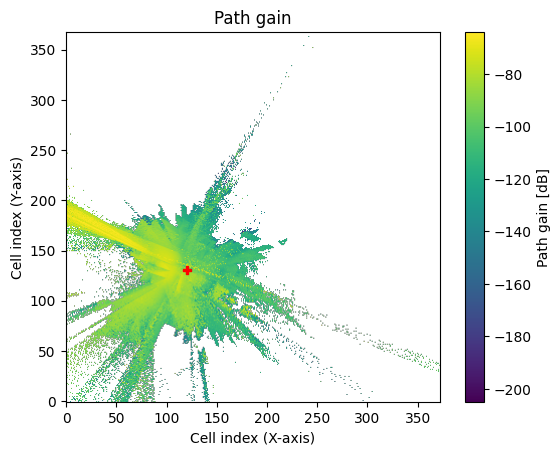

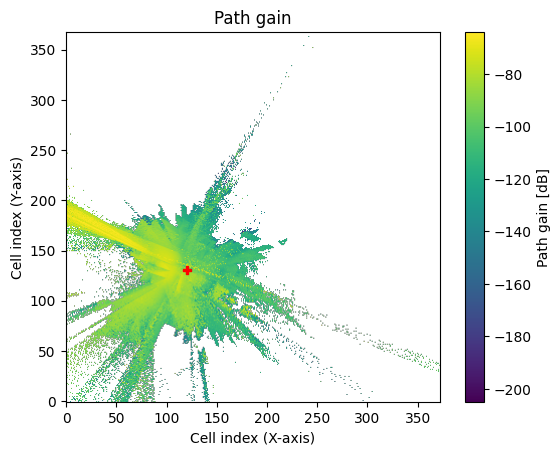

In [27]:
rs.show(metric="path_gain")

In [9]:
ps = PathSolver()
paths = ps(
    scene=scene,
    max_depth=5,
    los=True,                   # 直射路径
    specular_reflection=True,   # 镜面反射
    diffraction=True            # 绕射
)

In [34]:
scene.preview(paths=paths)

In [35]:
scene.preview(radio_map=rs, paths=paths)

<class 'matplotlib.figure.Figure'>


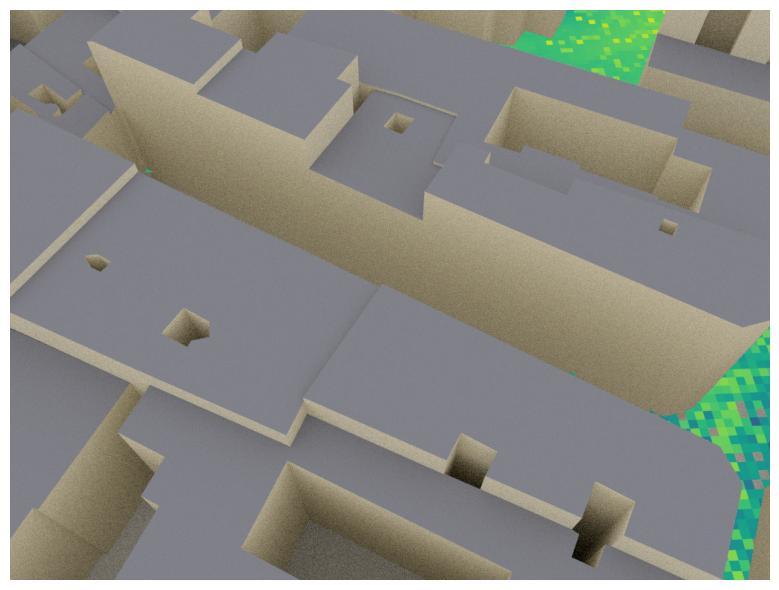

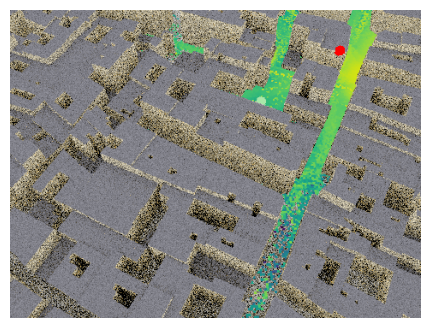

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
import mitsuba as mi

bmp = scene.render(
    camera="preview",
    radio_map=rs,
    resolution=(1024, 768),
    num_samples=64,
    return_bitmap=False
)

print(type(bmp))
# 1️⃣ 正确地把 Bitmap 转成 8-bit RGB
# bmp8 = bmp.convert(
#     pixel_format=mi.Bitmap.PixelFormat.RGB,      # 像素格式（枚举）
#     component_format=mi.Struct.Type.UInt8,        # 分量类型（枚举，不能用 "uint8"）
#     srgb_gamma=True                               # sRGB gamma
# )

# # 2️⃣ Bitmap -> NumPy array (H, W, 3)
# img = np.array(bmp8, copy=False)

# 3️⃣ 显示
plt.figure(figsize=(6,4))
plt.imshow(img)
plt.axis("off")
plt.show()

In [40]:
# 得到路径级 CIR（不是抽头）
a, tau = paths.cir(
    sampling_frequency=100e6, 
    normalize_delays=True,
    out_type="numpy"
)

print("a.shape =", a.shape)
print("tau.shape =", tau.shape)

a.shape = (1, 1, 1, 16, 198, 1)
tau.shape = (1, 1, 198)


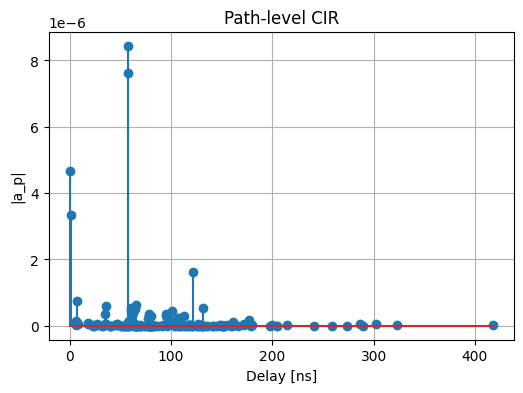

In [43]:
# 选一个 TX/RX/阵元（你当前是 1 RX + 16 TX）
a_p = np.abs(a[0,0,0,0,:,0])     # (P,)
# print(a_p)

tau_p = tau[0,0,:] * 1e9       # ns
# print(tau_p)
plt.figure(figsize=(6,4))
plt.stem(tau_p, a_p)
plt.xlabel("Delay [ns]")
plt.ylabel("|a_p|")
plt.title("Path-level CIR")
plt.grid(True)
plt.show()